# Pygame 图形与游戏

学习目标：用 Pygame 绘制二维画面，把输入、移动、碰撞与计分组成一个可重置、可退出的小型游戏。

前置知识：函数、类与对象、dataclass、模块导入、异常与 finally、文件路径、subprocess 和 pytest 断言。

运行环境：Python 3.12。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

图形示例使用 pygame 2.6.1；在线文档标注 2.6.0，本章使用其中的 2.6 系列 API。

Notebook 中的窗口和事件实验在有限运行的子进程内使用 dummy 显示驱动，不弹出窗口。交互游戏需要桌面显示环境与键盘；图形现场绘制，使用 Pygame 默认字体，无图片、声音下载及外部素材。截图写入临时目录或内存，展示后清理。

配套脚本：位于 [scripts/36-pygame/](scripts/36-pygame/)。

（1）[game\_logic.py](scripts/36-pygame/game_logic.py)：浮点位置、边界、碰撞、计分和重置规则。

（2）[collect\_game.py](scripts/36-pygame/collect_game.py)：完整游戏循环、画面绘制、交互与有限运行入口。

（3）[test\_game\_logic.py](scripts/36-pygame/test_game_logic.py)：固定输入的状态测试、事件队列与循环清理检查。

## 1 Surface、颜色与像素坐标

Surface 是保存图像像素的对象，创建普通 Surface 不等于创建窗口。尺寸用“宽、高”表示，单位是像素；坐标 (x, y) 中，x 表示从左向右的距离，y 表示从上向下的距离，左上角为 (0, 0)。

RGB 的三个分量依次表示红、绿、蓝，取值为 0～255 的整数。RGBA 还包含透明度分量 A，255 表示不透明。本章使用不透明颜色。

| 名称 | 中文名称／含义 | 本章用途 |
| --- | --- | --- |
| pygame.Surface | 图像表面 | 保存像素 |
| pygame.Color | 颜色对象 | 表示 RGB 或 RGBA 值 |
| Surface.fill | 填充颜色 | 清除画面或填充局部 |
| Surface.get\_at | 读取像素颜色 | 检查指定坐标 |

In [1]:
import os

# 隐藏导入时的欢迎语；这里不初始化显示模块。
os.environ["PYGAME_HIDE_SUPPORT_PROMPT"] = "1"
import pygame

canvas = pygame.Surface((160, 100))
canvas.fill((20, 30, 45))
print(canvas.get_size())  # (160, 100)：先宽后高。
print(tuple(canvas.get_at((0, 0))))  # (20, 30, 45, 255)
assert tuple(canvas.get_at((159, 99))) == (20, 30, 45, 255)

(160, 100)
(20, 30, 45, 255)


## 2 Rect 的位置、大小与边界

Rect 用整数保存矩形的 left、top、width、height，分别是左边、上边、宽和高。right 等于 left + width，bottom 等于 top + height；覆盖的像素不包含 right 和 bottom 边界。

colliderect 判断两个矩形是否重叠，仅边缘相接不算碰撞。Rect 描述几何范围，Surface 保存像素，两者常一起使用，但职责不同。

| 名称 | 中文名称／含义 |
| --- | --- |
| pygame.Rect | 整数矩形 |
| Rect.topleft | 左上角坐标 |
| Rect.right | 右侧排除边界 |
| Rect.bottom | 下侧排除边界 |
| Rect.collidepoint | 判断点是否在矩形内 |
| Rect.colliderect | 判断矩形是否重叠 |

In [2]:
box = pygame.Rect(10, 20, 30, 15)
touching = pygame.Rect(40, 20, 10, 10)
overlapping = pygame.Rect(39, 20, 10, 10)

print(box.right, box.bottom)  # 40 35：最后覆盖的像素是 (39, 34)。
print(box.collidepoint(39, 34), box.collidepoint(40, 35))
# True False：右边和下边都不包含在内。
print(box.colliderect(touching), box.colliderect(overlapping))
# False True：挪入一个像素后才有重叠。

40 35
True False
False True


## 3 绘制图形与复制图像

pygame.draw.rect 把矩形画到指定 Surface；width=0 填满矩形，正数表示边框线宽。这里的 width 是绘图参数，不是 Rect 的宽度。

Surface.blit 把另一张 Surface 复制到目标表面；位置参数指定源图像左上角放在哪里。按先背景、后物体的顺序绘制，后画的像素会覆盖前面的像素。本例同时用 draw.circle 画圆。

pygame.image.save 可以把 Surface 保存为 PNG。下面用 BytesIO 暂存图像字节，再由 IPython.display.Image 嵌入 Notebook；显示的是实际绘制结果。

(35, 35) (16, 16)


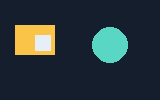

In [3]:
import io

import IPython.display

canvas.fill((20, 30, 45))
pygame.draw.rect(canvas, (250, 196, 72), (15, 25, 40, 30))
pygame.draw.circle(canvas, (90, 215, 196), (110, 45), 18)
badge = pygame.Surface((16, 16))
badge.fill((232, 238, 248))
changed = canvas.blit(badge, (35, 35))

print(changed.topleft, changed.size)  # (35, 35) (16, 16)
assert tuple(canvas.get_at((36, 36)))[:3] == (232, 238, 248)
with io.BytesIO() as buffer:
    pygame.image.save(canvas, buffer, "shapes.png")
    IPython.display.display(IPython.display.Image(data=buffer.getvalue()))
# 白色方块覆盖金色矩形的一部分；右边另有一个绿色圆形。

### 3.1 移动前清除旧画面

改变坐标不会自动擦掉之前画下的像素。每帧先填充背景，再按当前状态重画，才能避免留下旧位置的图形。下面只检查一个旧位置的像素，不启动循环。

In [4]:
trail = pygame.Surface((100, 40))
background = (20, 30, 45)
player_color = (90, 215, 196)
trail.fill(background)
pygame.draw.rect(trail, player_color, (5, 5, 12, 12))
pygame.draw.rect(trail, player_color, (30, 5, 12, 12))
print(tuple(trail.get_at((6, 6)))[:3])  # 旧位置仍是玩家颜色。

trail.fill(background)
pygame.draw.rect(trail, player_color, (30, 5, 12, 12))
print(tuple(trail.get_at((6, 6)))[:3])  # (20, 30, 45)：旧位置已清除。
assert tuple(trail.get_at((31, 6)))[:3] == player_color

(90, 215, 196)
(20, 30, 45)


## 4 显示画面与释放资源

pygame.display.set\_mode 返回显示 Surface；绘制后调用 pygame.display.flip，才把完整画面提交给显示系统。pygame.quit 释放已初始化的模块，但不会结束 Python 程序；退出循环与释放资源是两个步骤。

SDL\_VIDEODRIVER 在显示模块初始化前选择驱动。辅助函数 run\_headless 把 dummy 设置在子进程环境中，再导入 Pygame，避免打开桌面窗口。它只执行本章直接写出的可信代码，并设置 15 秒超时。子进程工作目录仍为 Notebook 目录。PYTHONIOENCODING=utf-8 固定子进程标准流编码，与父进程的 UTF-8 解码保持一致。

In [5]:
import subprocess
import sys
import textwrap
from pathlib import Path

script_dir = Path("scripts/36-pygame").resolve()
headless_env = os.environ.copy()
# dummy 驱动仅用于可复现的无窗口实验，交互游戏使用正常显示驱动。
headless_env.update({
    "SDL_VIDEODRIVER": "dummy",
    "PYGAME_HIDE_SUPPORT_PROMPT": "1",
    "PYTHONDONTWRITEBYTECODE": "1",
    "PYTHONIOENCODING": "utf-8",
    "PYTHONPATH": str(script_dir),
})


def run_headless(source: str) -> str:
    """在无窗口子进程中运行本章可信示例，返回文本输出。"""
    completed = subprocess.run(
        [sys.executable, "-B", "-c", textwrap.dedent(source)],
        cwd=Path.cwd(),
        env=headless_env,
        capture_output=True,
        text=True,
        encoding="utf-8",
        check=True,
        timeout=15,
    )
    print(completed.stderr, end="")  # 通常为空；若平台产生诊断则原样保留。
    return completed.stdout


print(run_headless("""
    import pygame

    try:
        pygame.display.init()
        screen = pygame.display.set_mode((160, 100))
        # 先清背景，再画矩形，最后 flip 提交完整一帧。
        screen.fill((20, 30, 45))
        pygame.draw.rect(screen, (250, 196, 72), (20, 20, 30, 30))
        pygame.display.flip()
        print(screen.get_size())  # (160, 100)。
    finally:
        pygame.quit()
    print(pygame.display.get_init())  # False：显示模块已经关闭。
"""), end="")
# (160, 100) 与 False：完成一次绘制，显示模块已关闭。

(160, 100)
False


## 5 事件与持续按键状态

### 5.1 用事件处理一次命令

事件队列保存关闭窗口、按下按键等消息。pygame.event.get 取出并移除队列中的事件，默认也处理底层事件；每帧都应取出并处理事件，避免队列积满及错过退出请求。

QUIT 表示退出请求；KEYDOWN 表示按键按下，event.key 指明按键。初始化时按键重复默认关闭；若主动启用重复，同一次长按也可能产生多条 KEYDOWN。

pygame.event.Event 构造事件，pygame.event.post 把事件放入队列。下面人为提供 R 和退出事件，观察处理顺序。

In [6]:
print(run_headless("""
    import pygame

    try:
        pygame.display.init()
        pygame.display.set_mode((64, 48))
        pygame.event.clear()  # 仅清理本实验开始时的系统事件。
        # 人工投递两个离散事件，随后观察队列按序取出后变空。
        restart = pygame.event.Event(pygame.KEYDOWN, key=pygame.K_r)
        assert pygame.event.post(restart)
        assert pygame.event.post(pygame.event.Event(pygame.QUIT))

        commands = []
        for event in pygame.event.get():
            if event.type == pygame.KEYDOWN and event.key == pygame.K_r:
                commands.append("restart")
            elif event.type == pygame.QUIT:
                commands.append("quit")
        print(commands)  # ['restart', 'quit']；保持投递顺序。
        print(len(pygame.event.get()))  # 0；上一轮已取走事件。
    finally:
        pygame.quit()
"""), end="")
# ['restart', 'quit']，随后为 0：取出的事件不再留在队列。

['restart', 'quit']
0


### 5.2 用当前状态控制持续移动

pygame.key.get\_pressed 返回当前各按键是否按下，应使用 pygame.K\_RIGHT 等常量索引。它适合持续移动，不能提供按键先后顺序，也可能错过两次读取之间的快速按下与松开。

游戏用 KEYDOWN 处理 R 重置，用 get\_pressed 处理方向键。人工投递事件与查询设备状态分别观察；下面另给一组布尔输入计算方向，不依靠真实键盘操作。

In [7]:
print(run_headless("""
    import pygame

    try:
        pygame.display.init()
        pygame.display.set_mode((64, 48))
        pygame.event.clear()
        event = pygame.event.Event(pygame.KEYDOWN, key=pygame.K_RIGHT)
        assert pygame.event.post(event)
        events = pygame.event.get()
        print(any(item.type == pygame.KEYDOWN for item in events))  # True：队列中有人工投递的按下事件。
        print(pygame.key.get_pressed()[pygame.K_RIGHT])  # 本次 dummy 实验为 False，未形成物理长按状态。
    finally:
        pygame.quit()
"""), end="")
# 本次 dummy 实验为 True、False：入队事件没有变成物理长按状态。

# 持续移动使用当前按键状态；相反方向相减，把每个轴编码为 -1、0、1。
held = {"right": True, "left": False, "down": True, "up": False}
direction = pygame.Vector2(
    int(held["right"]) - int(held["left"]),
    int(held["down"]) - int(held["up"]),
)
print(tuple(direction))  # (1.0, 1.0)：右下方向；相反按键同时按下会抵消。

True
False
(1.0, 1.0)


## 6 按经过时间计算位移

Clock.tick 每帧调用一次，返回距上次调用经过的毫秒数；tick(60) 会适当等待以限制帧率，但不保证每帧恰好耗时 1/60 秒。将返回值除以 1000，得到以秒为单位的 dt。

本章速度 speed 的单位是像素／秒，单方向位移为 speed × dt。游戏把每帧参与更新的 dt 限制到最多 0.05 秒，避免长时间停顿后一次跳太远。这是本例的规则，会舍弃超过上限的时间，并非 Pygame 自动处理。

In [8]:
print(run_headless("""
    import pygame

    try:
        clock = pygame.time.Clock()
        measured_ms = clock.tick(60)
        dt = measured_ms / 1000
        print(isinstance(measured_ms, int), dt >= 0)  # True True；不固定实际毫秒数。
    finally:
        pygame.quit()
"""), end="")
# True True：只检查返回单位和范围，不把计时噪声当作固定结果。

speed = 180.0
for measured_ms in (10, 25, 500):
    dt = min(measured_ms / 1000, 0.05)
    print(round(speed * dt, 2))
# 1.8、4.5、9.0 像素；最后一次按上限 0.05 秒计算。

True True
1.8
4.5
9.0


## 7 浮点位置与方向向量

Vector2 保存二维数值，适合累加浮点位置。Rect 的坐标是整数；本例只在绘图和碰撞时用 int 转换位置，不把取整后的坐标写回 Vector2，保留不足一个像素的移动。

方向向量的长度表示其大小。normalize 返回方向相同、长度为 1 的新向量；本例仅对非零方向调用它，使斜向和横向在相同时间内移动相同距离。

In [9]:
position = pygame.Vector2(40, 200)
for _ in range(10):
    position += pygame.Vector2(1, 0) * 180 * 0.001
pixel_box = pygame.Rect(int(position.x), int(position.y), 24, 24)
print(round(position.x, 2), pixel_box.x)  # 41.8 41：小数位移没有逐帧丢失。

diagonal = pygame.Vector2(1, 1)
step = diagonal.normalize() * 180 * 0.05
print(round(step.length(), 2))  # 9.0：斜向的总距离仍为 9 像素。

41.8 41
9.0


## 8 保存状态并限制活动范围

配套模块 GameState 保存一局游戏的数据；update 接收方向与秒数，先移动，再限制边界，最后检查碰撞。活动区为 Rect(24, 96, 592, 240)，玩家尺寸为 24 × 24 像素，因此玩家左上角的 x 范围为 24～592，y 范围为 96～312。

限制范围时必须减去玩家尺寸，才能让整个方块留在活动区。先限制浮点位置，再派生整数碰撞框，避免浮点状态与画面脱离。下面把配套目录临时加入模块搜索路径，仅用于本章导入。

| 字段或属性 | 中文名称／含义 |
| --- | --- |
| position | 玩家左上角的浮点位置 |
| player\_rect | 玩家整数碰撞框 |
| target\_rect | 当前目标矩形 |
| score | 累计收集数量 |
| target\_index | 固定目标序列中的索引 |
| running | 是否继续游戏 |

In [10]:
sys.path.insert(0, str(script_dir))
try:
    import game_logic
finally:
    sys.path.pop(0)

state = game_logic.GameState(position=pygame.Vector2(591, 311))
state.update(pygame.Vector2(1, 1), 0.05)
print(tuple(state.position))  # (592.0, 312.0)：玩家右下角恰好到达边界。
assert pygame.Rect(game_logic.ARENA).contains(state.player_rect)

state = game_logic.GameState(position=pygame.Vector2(25, 97))
state.update(pygame.Vector2(-1, -1), 0.05)
print(tuple(state.position))  # (24.0, 96.0)：左上边界也受限制。

(592.0, 312.0)
(24.0, 96.0)


### 8.1 碰撞后计分并切换目标

游戏让绿色玩家收集金色目标，每次重叠加 1 分，随后按四个固定位置循环选择目标，不使用随机数。每帧只处理当前目标一次，避免在一帧里重复计分。

本章只检查更新后的两个 Rect 是否重叠，不检查整段运动路径。限制 dt 能约束本例的单帧位移，但不能把这种检查推广为任意速度、尺寸下都不会穿过目标的保证。

In [11]:
state = game_logic.GameState(position=pygame.Vector2(96, 200))
state.update(pygame.Vector2(), 0)
print(state.score)  # 0：玩家右边为 120，只与目标左边相接。

state.update(pygame.Vector2(1, 0), 0.01)
print(state.score, state.target_rect.topleft)  # 1 (400, 140)
state.update(pygame.Vector2(), 0)
print(state.score)  # 仍为 1：停在旧目标处不会反复加分。

0
1 (400, 140)
1


### 8.2 重置和退出是不同的状态变化

R 重置位置、分数和目标索引；QUIT 或 Esc 让 running 变为 False。处理退出后立即停止当前批次的事件处理，也不再更新位置。

这里把事件直接交给状态对象，用于检查规则；第五节已经观察过事件如何经过真实队列。状态检查不需要创建窗口。

In [12]:
restart = pygame.event.Event(pygame.KEYDOWN, key=pygame.K_r)
state.handle_events([restart])
print(state.score, tuple(state.position), state.target_rect.topleft)
# 0、(40.0, 200.0)、(120, 200)：一局数据同时恢复。

state.handle_events([pygame.event.Event(pygame.QUIT), restart])
state.update(pygame.Vector2(1, 0), 0.05)
print(state.running, tuple(state.position))
# False (40.0, 200.0)：同批次的 R 不撤销退出，位置也不再推进。

0 (40.0, 200.0) (120, 200)
False (40.0, 200.0)


## 9 组成完整游戏循环

collect\_game.py 的每帧顺序是：处理退出与重置事件，读取持续按键，更新位置并处理碰撞，填充背景并绘制当前状态，最后调用 display.flip。Clock.tick 提供该帧用于更新的时间。

画面上的文字由 pygame.font.Font(None, 28) 使用默认字体生成。Font.render 返回文字 Surface，再用 blit 放到显示 Surface；字体在循环外创建，图形与文字按当前分数重画。

在 Notebook 目录的终端激活共享环境后，运行 python scripts/36-pygame/collect\_game.py 即可交互。方向键移动，R 重来，Esc 或关闭窗口退出；普通运行不要设置 SDL\_VIDEODRIVER=dummy。下面只运行有限模式：--frames 必须为正整数，--dt 是固定秒数且需与 --frames 同用，达到帧数后脚本投递 QUIT 并关闭资源。

{'frames': 8, 'score': 0, 'position': [40.0, 200.0], 'running': False, 'display_closed': True}


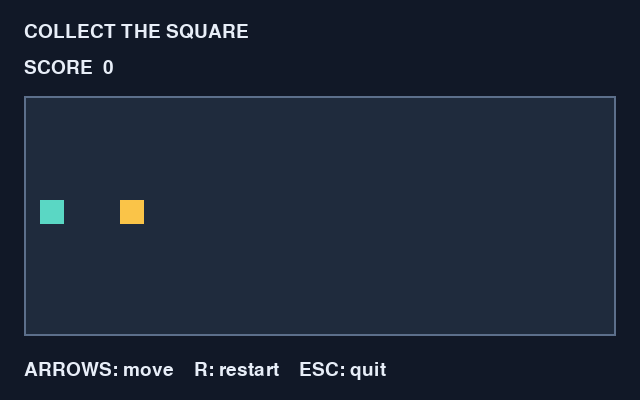

In [13]:
import json
import tempfile

with tempfile.TemporaryDirectory(dir=script_dir) as temp_dir:
    snapshot = Path(temp_dir) / "game.png"
    # 固定帧数和每帧秒数，让完整游戏循环自动结束并留下实际截图。
    completed = subprocess.run(
        [
            sys.executable, "-B", str(script_dir / "collect_game.py"),
            "--frames", "8", "--dt", "0.025",
            "--snapshot", str(snapshot),
        ],
        cwd=Path.cwd(),
        env=headless_env,
        capture_output=True,
        text=True,
        encoding="utf-8",
        check=True,
        timeout=15,
    )
    print(completed.stderr, end="")  # 通常为空；平台诊断原样显示。
    report = json.loads(completed.stdout)
    print(report)  # frames=8、score=0、position=[40.0, 200.0]、running=False、display_closed=True。
    assert report["frames"] == 8
    assert report["score"] == 0
    assert report["position"] == [40.0, 200.0]
    assert not report["running"] and report["display_closed"]
    # 读取图片字节嵌入输出，退出临时目录后仍可在 Notebook 中查看。
    IPython.display.display(
        IPython.display.Image(data=snapshot.read_bytes()),
    )
# 无方向输入，8 帧后自动退出；得分为 0，图中保留初始玩家和目标。
# 截图字节已嵌入输出，with 结束后删除临时图片和目录。

## 10 拒绝无效输入并保证清理

参数解析不能把 0 帧、负时间或非有限时间当成正常实验。CLI 用 argparse 给出用法错误；状态更新另以 ValueError 拒绝无效 dt。这里只检查已知错误，不吞掉其它失败。

无论正常退出还是绘制阶段失败，游戏都在 finally 调用 pygame.quit。显示模块和字体模块按需初始化；不用初始化音频模块，也不依赖解释器结束来关闭窗口。

In [14]:
# 这些参数测试针对 CLI 用法；check=False 用来观察约定的非零退出。
for arguments in (
    ["--frames", "0"],
    ["--frames", "1", "--dt", "-0.01"],
    ["--frames", "1", "--dt", "nan"],
    ["--dt", "0.02"],
):
    rejected = subprocess.run(
        [sys.executable, "-B", str(script_dir / "collect_game.py"), *arguments],
        cwd=Path.cwd(),
        env=headless_env,
        capture_output=True,
        text=True,
        encoding="utf-8",
        check=False,
        timeout=15,
    )
    print(arguments, rejected.returncode)
    assert rejected.returncode == 2
    assert "error:" in rejected.stderr  # 中文诊断已成功解码。
# 四组参数均为用法错误，返回 2，不进入游戏循环。

try:
    game_logic.GameState().update(pygame.Vector2(1, 0), -0.01)
except ValueError as error:
    print(type(error).__name__)  # ValueError：负时间不能进入状态计算。
else:
    raise AssertionError("负 dt 没有被拒绝")

['--frames', '0'] 2


['--frames', '1', '--dt', '-0.01'] 2


['--frames', '1', '--dt', 'nan'] 2


['--dt', '0.02'] 2
ValueError


## 11 用固定输入检查游戏规则

图形程序也可以把状态规则独立检查。配套测试用明确的位置、方向、时间和事件，覆盖边缘相接、重叠计分、目标轮换、重置、边界及 dt 限制。

循环测试只替代物理键盘查询，真正执行 SDL 事件处理、10 帧移动、碰撞、绘图、PNG 保存和清理；另一项测试让绘制函数抛出预定错误，检查 finally 仍关闭资源。这些无窗口检查不能替代真实键盘、桌面窗口和显示驱动的交互检查。

In [15]:
test_env = headless_env | {"PYTEST_DISABLE_PLUGIN_AUTOLOAD": "1"}
# 测试用固定输入驱动游戏规则；测试临时文件随本次运行自动清理。
with tempfile.TemporaryDirectory(dir=script_dir) as temp_dir:
    tested = subprocess.run(
        [
            sys.executable, "-B", "-m", "pytest",
            str(script_dir / "test_game_logic.py"),
            "-q", "-p", "no:cacheprovider",
            "--basetemp", str(Path(temp_dir) / "pytest"),
        ],
        cwd=Path.cwd(),
        env=test_env,
        capture_output=True,
        text=True,
        encoding="utf-8",
        check=True,
        timeout=15,
    )
    print(tested.stdout, end="")  # 19 passed；测试耗时不是固定值。
    print(tested.stderr, end="")  # 正常测试时为空；额外诊断原样显示。
# 所有行为断言应通过；耗时由实际运行决定，临时截图和测试目录自动删除。

...................                                                      [100%]
19 passed in 1.41s


## 本章小结

Surface 保存像素，Rect 表示整数范围，Vector2 保存浮点状态。事件适合一次命令，按键状态适合持续移动；按秒计算位移后，再限制时间与活动边界。

游戏循环按输入、更新与碰撞、绘制的顺序推进，退出循环后还要释放资源。自查：为什么不能每帧把 Rect 的整数坐标写回浮点位置？为什么“收到了 KEYDOWN”和“这个键现在仍按着”不是同一项观察？

## 练习

### 1 预测矩形边界

先写出下面三个布尔值，再运行核对。解释每次判断比较的是哪条边，以及接触与重叠的区别；不要只记住输出顺序。

In [16]:
first = pygame.Rect(5, 5, 10, 10)
second = pygame.Rect(15, 5, 10, 10)
print(first.collidepoint(14, 14))
print(first.colliderect(second))
second.x -= 1
print(first.colliderect(second))
# 运行前先记录预测，运行后按 Rect 的坐标区间逐项核对。

True
False
True


### 2 检查时间上限

不修改配套实现，分别新建三局：第一局向右更新一次 0.05 秒；第二局向右更新两次 0.025 秒；第三局向右更新一次 0.5 秒。

用断言检查三局横坐标相等且纵坐标不变，并说明最后一局为何没有移动十倍距离。为负数、NaN 和正无穷时间分别检查 ValueError，不能用宽泛异常捕获代替。

### 3 检查退出优先级

分别测试“QUIT 后接 R”和“Esc 后接 R”两个事件列表。每次用全新状态，处理事件后再尝试移动；断言 running 为 False，分数和位置不变。

最后在有桌面显示的终端手动运行交互游戏：持续按方向键应移动，贴边后仍留在活动区，碰到金色方块后分数加 1，R 恢复初始状态，Esc 关闭窗口。分别记录状态断言与手动操作是否完成。

## 参考与引用来源

| 网站 | 核查位置、版本与支持内容 |
| --- | --- |
| pygame.org | 在线文档标注 pygame 2.6.0，本章使用 2.6 系列接口，运行依赖为 2.6.1。[Surface、fill、blit、get\_at](https://www.pygame.org/docs/ref/surface.html#pygame.Surface)、[RGB 与 RGBA](https://www.pygame.org/docs/ref/color.html#pygame.Color)、[坐标与重画](https://www.pygame.org/docs/tut/MoveIt.html#going-from-the-list-to-the-screen)、[Rect 边界](https://www.pygame.org/docs/ref/rect.html#pygame.Rect)、[colliderect](https://www.pygame.org/docs/ref/rect.html#pygame.Rect.colliderect)、[矩形绘制](https://www.pygame.org/docs/ref/draw.html#pygame.draw.rect)、[圆形绘制](https://www.pygame.org/docs/ref/draw.html#pygame.draw.circle)、[显示初始化与驱动](https://www.pygame.org/docs/ref/display.html#pygame.display.init)、[set\_mode](https://www.pygame.org/docs/ref/display.html#pygame.display.set_mode)、[flip](https://www.pygame.org/docs/ref/display.html#pygame.display.flip)、[事件类型和队列限制](https://www.pygame.org/docs/ref/event.html)、[get](https://www.pygame.org/docs/ref/event.html#pygame.event.get)、[post](https://www.pygame.org/docs/ref/event.html#pygame.event.post)、[持续按键](https://www.pygame.org/docs/ref/key.html#pygame.key.get_pressed)、[重复按键](https://www.pygame.org/docs/ref/key.html#pygame.key.set_repeat)、[Clock.tick 的毫秒单位](https://www.pygame.org/docs/ref/time.html#pygame.time.Clock.tick)、[Vector2](https://www.pygame.org/docs/ref/math.html#pygame.math.Vector2)、[normalize](https://www.pygame.org/docs/ref/math.html#pygame.math.Vector2.normalize)、[默认字体](https://www.pygame.org/docs/ref/font.html#pygame.font.Font)、[文字 Surface](https://www.pygame.org/docs/ref/font.html#pygame.font.Font.render)、[保存 PNG](https://www.pygame.org/docs/ref/image.html#pygame.image.save)、[初始化与 quit](https://www.pygame.org/docs/ref/pygame.html#pygame.quit)。 |
| github.com | Pygame 维护者仓库的 2.6.1 标签：[事件 get 与 post](https://github.com/pygame/pygame/blob/2.6.1/docs/reST/ref/event.rst)、[Font 与 render](https://github.com/pygame/pygame/blob/2.6.1/docs/reST/ref/font.rst)、[图像保存与 namehint](https://github.com/pygame/pygame/blob/2.6.1/docs/reST/ref/image.rst)、[Vector2 的分量与归一化](https://github.com/pygame/pygame/blob/2.6.1/docs/reST/ref/math.rst)；SDL 维护者源码 release-2.28.4：[dummy 驱动实现，DUMMYVID\_DRIVER\_NAME 与 DUMMY\_CreateDevice](https://github.com/libsdl-org/SDL/blob/release-2.28.4/src/video/dummy/SDL_nullvideo.c#L51)。 |
| wiki.libsdl.org | SDL2 [选择显示驱动](https://wiki.libsdl.org/SDL2/FAQUsingSDL#how-do-i-choose-a-specific-video-driver)：环境变量控制与平台、构建条件。 |
| docs.python.org | Python 3.12：[标准流编码](https://docs.python.org/3.12/library/sys.html#sys.stdout)、[PYTHONIOENCODING](https://docs.python.org/3.12/using/cmdline.html#envvar-PYTHONIOENCODING)、[subprocess.run 的 env、check 与 timeout](https://docs.python.org/3.12/library/subprocess.html#subprocess.run)、[TemporaryDirectory 清理](https://docs.python.org/3.12/library/tempfile.html#tempfile.TemporaryDirectory)、[argparse 类型转换](https://docs.python.org/3.12/library/argparse.html#type)。 |
| ipython.readthedocs.io | IPython 9.17.1 文档：[Image 的字节输入与嵌入显示](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.Image)。 |